In [77]:
# 🖼 Dataset & Transforms
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 🔧 Core PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# 📈 Visualization
import matplotlib.pyplot as plt

# 🔣 Math utilities
import math

# Progress visualization utility
from tqdm import tqdm

# 🧪 Optional: If using Curvy or Hessian
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy

In [78]:
# Seed everything
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
])

train_dataset = datasets.Imagenette(root='./data', split='train', transform=transform, download=True)
test_dataset = datasets.Imagenette(root='./data', split='val', transform=transform, download=True)

ValueError: Unknown value 'test' for argument split. Valid values are {'train', 'val'}.

In [80]:
print(len(train_dataset), len(test_dataset))

9469 3925


In [12]:

def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=True):
    # Adapted from MAE paper: https://github.com/facebookresearch/mae
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_w, grid_h, indexing='ij')  # (H, W)
    grid = torch.stack(grid, dim=0)  # (2, H, W)
    grid = grid.reshape(2, 1, grid_size, grid_size)
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = torch.cat([torch.zeros([1, embed_dim]), pos_embed], dim=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 4 == 0
    emb_h = get_1d_sincos_pos_embed(embed_dim // 2, grid[0])  # x
    emb_w = get_1d_sincos_pos_embed(embed_dim // 2, grid[1])  # y
    return torch.cat([emb_h, emb_w], dim=1)

def get_1d_sincos_pos_embed(embed_dim, pos):
    omega = torch.arange(embed_dim // 2, dtype=torch.float32)
    omega /= embed_dim / 2.
    omega = 1. / (10000 ** omega)  # (dim/2,)

    pos = pos.reshape(-1)  # flatten
    out = torch.einsum('p,d->pd', pos, omega)  # (pos, dim/2)

    emb_sin = torch.sin(out)
    emb_cos = torch.cos(out)
    return torch.cat([emb_sin, emb_cos], dim=1)  # (pos, dim)

class SimpleViT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=10, dim=256, depth=4, heads=4, mlp_dim=512):
        super().__init__()
        assert image_size % patch_size == 0, 'Image dimensions must be divisible by patch size.'

        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        patch_dim = 3 * patch_size * patch_size

        self.patch_embedding = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim), requires_grad=True)
        pos_embed = get_2d_sincos_pos_embed(dim, int(math.sqrt(self.num_patches)))
        self.register_buffer('pos_embedding', pos_embed.unsqueeze(0))  # [1, num_patches+1, dim]

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p).contiguous()
        x = x.view(B, C, -1, p, p).permute(0, 2, 1, 3, 4)
        x = x.reshape(B, self.num_patches, -1)
        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding

        x = self.transformer(x)
        return self.mlp_head(x[:, 0])


In [82]:
model = SimpleViT(image_size=224, patch_size=16, num_classes=10)
# Number of parameters in model:
print(f"Number of parameters in model: {sum(p.numel() for p in model.parameters())}")

Number of parameters in model: 2308618


In [83]:
def train_vit(optimizer_class, use_curvy=False, batch_size=128, **optimizer_kwargs):
	device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
	# Use the same seed for reproducibility
	g = torch.Generator().manual_seed(42)
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, generator=g)
	test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, generator=g)


	model = SimpleViT(image_size=224, patch_size=16, num_classes=10)
	model = model.to(device)

	if use_curvy:
		optimizer = optimizer_class(model.parameters(), model=model, **optimizer_kwargs)
	else:
		optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

	criterion = nn.CrossEntropyLoss()
	num_epochs = 20
	train_losses, test_losses = [], []

	for epoch in range(num_epochs):
		model.train()
		train_loss = 0.0
		pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
		for data, target in pbar:
			data, target = data.to(device), target.to(device)
			optimizer.zero_grad()
			output = model(data)
			loss = criterion(output, target)
			loss.backward()
			optimizer.step()
			train_loss += loss.item()
			pbar.set_postfix({'batch_loss': loss.item()})
		train_loss /= len(train_loader)
		train_losses.append(train_loss)

		model.eval()
		test_loss, total, total_correct = 0.0, 0, 0
		with torch.no_grad():
			for data, target in test_loader:
				data, target = data.to(device), target.to(device)
				output = model(data)
				loss = criterion(output, target)
				test_loss += loss.item()
				_, predicted = output.max(1)
				total += target.size(0)
				total_correct += predicted.eq(target).sum().item()
		test_loss /= len(test_loader)
		test_losses.append(test_loss)

		# print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {total_correct/total:.4f}')
		print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, "
      f"Test Loss: {test_loss:.4f}, Test Accuracy: {total_correct/total:.4f}")

	plt.figure(figsize=(10, 6))
	plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
	plt.plot(range(1, num_epochs+1), test_losses, label='Testing Loss')
	plt.xlabel('Epoch')
	plt.ylabel('Loss')
	plt.title('Training and Testing Loss Curves')
	plt.legend()
	plt.grid(True)
	plt.show()

	return model, train_losses, test_losses


Epoch 1/20: 100%|██████████| 74/74 [00:16<00:00,  4.43it/s, batch_loss=2.04]


Epoch 1/20 - Train Loss: 2.1684, Test Loss: 1.9883, Test Accuracy: 0.2848


Epoch 2/20: 100%|██████████| 74/74 [00:17<00:00,  4.31it/s, batch_loss=1.78]


Epoch 2/20 - Train Loss: 1.9461, Test Loss: 1.8036, Test Accuracy: 0.3750


Epoch 3/20: 100%|██████████| 74/74 [00:16<00:00,  4.41it/s, batch_loss=1.59]


...

Epoch 18/20 - Train Loss: 1.2550, Test Loss: 1.2290, Test Accuracy: 0.5926


Epoch 19/20: 100%|██████████| 74/74 [00:16<00:00,  4.43it/s, batch_loss=1.09] 


Epoch 19/20 - Train Loss: 1.2108, Test Loss: 1.2292, Test Accuracy: 0.5707


Epoch 20/20: 100%|██████████| 74/74 [00:16<00:00,  4.43it/s, batch_loss=1.29]


Epoch 20/20 - Train Loss: 1.2340, Test Loss: 1.2663, Test Accuracy: 0.5829


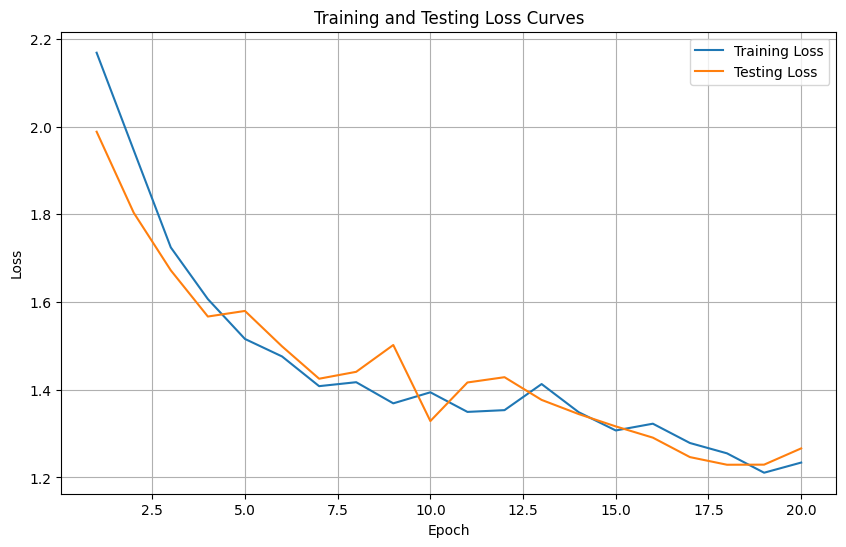

In [84]:
model, train_losses, test_losses = train_vit(optim.Adam, lr=1e-3)

In [ ]:
type(train_dataset[0][0])

torch.Tensor

Epoch 1/20:  66%|██████▌   | 49/74 [00:11<00:05,  4.91it/s, batch_loss=2.23]/home/aarsh.wankar/Hessian/DeepHessian/Curvy/curvy.py:97: UserWarning: Hessian computation failed: 'list' object has no attribute 'size'
  
Epoch 1/20: 100%|██████████| 74/74 [00:17<00:00,  4.31it/s, batch_loss=2.18]


Epoch 1/20 - Train Loss: 2.2094, Test Loss: 2.1281, Test Accuracy: 0.2186


Epoch 2/20: 100%|██████████| 74/74 [00:17<00:00,  4.23it/s, batch_loss=2.05]


Epoch 2/20 - Train Loss: 2.0976, Test Loss: 2.0609, Test Accuracy: 0.2744


Epoch 3/20: 100%|██████████| 74/74 [00:17<00:00,  4.23it/s, batch_loss=1.92]


...

Epoch 18/20 - Train Loss: 1.4978, Test Loss: 1.5050, Test Accuracy: 0.5050


Epoch 19/20: 100%|██████████| 74/74 [00:17<00:00,  4.29it/s, batch_loss=1.43]


Epoch 19/20 - Train Loss: 1.4664, Test Loss: 1.4527, Test Accuracy: 0.5205


Epoch 20/20: 100%|██████████| 74/74 [00:19<00:00,  3.87it/s, batch_loss=1.34]


Epoch 20/20 - Train Loss: 1.4340, Test Loss: 1.4272, Test Accuracy: 0.5162


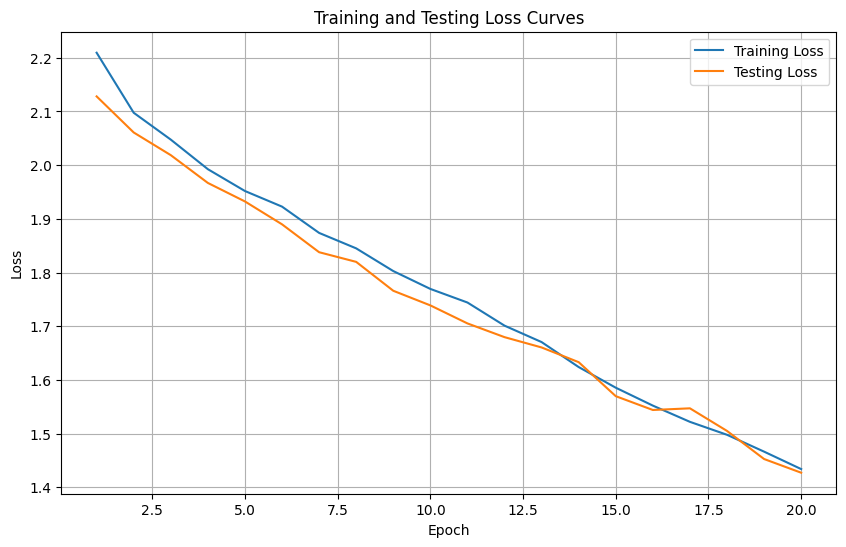

In [ ]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import torch.nn as nn

curvy_model, curvy_train, curvy_test = train_vit(
    optimizer_class=Curvy,
    use_curvy=True,
    lr=1e-5,
    hessian_epsilon=1e-3,
    momentum=0.9,
    hessian_compute_interval=50,
    hessian_n_iter=100,
    criterion=nn.CrossEntropyLoss(),
    hessian_computer=hessian,
    train_x=[train_dataset[i][0] for i in range(len(train_dataset))],
    train_y=[train_dataset[i][1] for i in range(len(train_dataset))],
    cuda=True
)


Epoch 1/20: 100%|██████████| 74/74 [00:18<00:00,  3.91it/s, batch_loss=2.18]


Epoch 1/20 - Train Loss: 2.2287, Test Loss: 2.1479, Test Accuracy: 0.2262


Epoch 2/20: 100%|██████████| 74/74 [00:18<00:00,  4.06it/s, batch_loss=2.07]


Epoch 2/20 - Train Loss: 2.1075, Test Loss: 2.0616, Test Accuracy: 0.2757


Epoch 3/20: 100%|██████████| 74/74 [00:18<00:00,  4.01it/s, batch_loss=1.95]


...

Epoch 18/20 - Train Loss: 1.5587, Test Loss: 1.5889, Test Accuracy: 0.4652


Epoch 19/20: 100%|██████████| 74/74 [00:17<00:00,  4.23it/s, batch_loss=1.44]


Epoch 19/20 - Train Loss: 1.5345, Test Loss: 1.5161, Test Accuracy: 0.4948


Epoch 20/20: 100%|██████████| 74/74 [00:18<00:00,  4.09it/s, batch_loss=1.48]


Epoch 20/20 - Train Loss: 1.4934, Test Loss: 1.4769, Test Accuracy: 0.5088


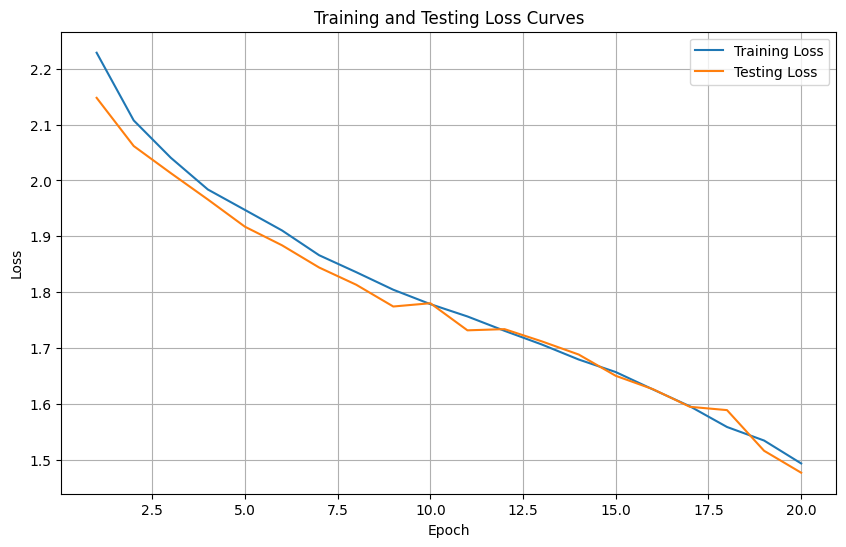

In [92]:
model, train_losses, test_losses = train_vit(optim.SGD, lr=1e-3, momentum=0.9)


Epoch 1/20: 100%|██████████| 74/74 [00:20<00:00,  3.61it/s, batch_loss=2.04]


Epoch 1/20 - Train Loss: 2.1755, Test Loss: 2.0867, Test Accuracy: 0.2558


Epoch 2/20: 100%|██████████| 74/74 [00:19<00:00,  3.73it/s, batch_loss=1.83]


Epoch 2/20 - Train Loss: 1.9623, Test Loss: 1.9009, Test Accuracy: 0.3361


Epoch 3/20: 100%|██████████| 74/74 [00:18<00:00,  4.07it/s, batch_loss=1.75]


...

Epoch 18/20 - Train Loss: 0.8998, Test Loss: 0.9896, Test Accuracy: 0.6843


Epoch 19/20: 100%|██████████| 74/74 [00:18<00:00,  4.06it/s, batch_loss=0.882]


Epoch 19/20 - Train Loss: 0.9090, Test Loss: 1.0646, Test Accuracy: 0.6604


Epoch 20/20: 100%|██████████| 74/74 [00:17<00:00,  4.16it/s, batch_loss=0.901]


Epoch 20/20 - Train Loss: 0.8716, Test Loss: 0.9760, Test Accuracy: 0.6897


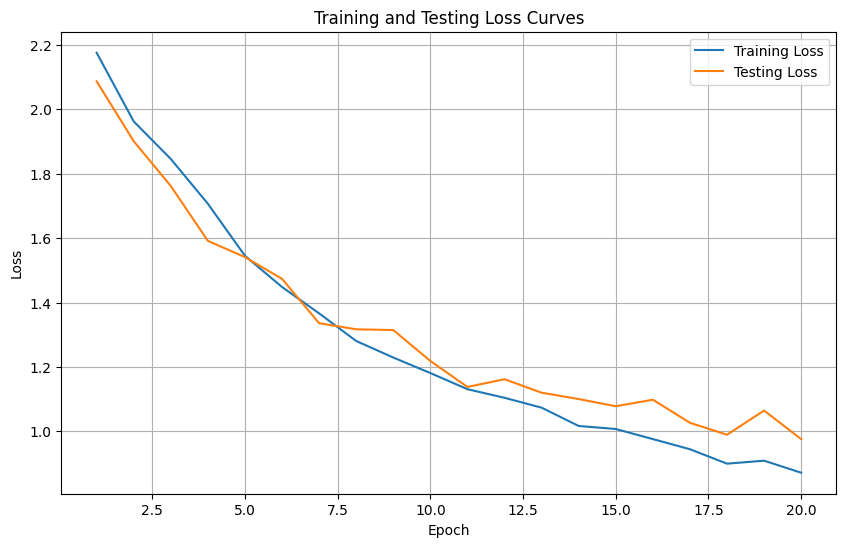

In [93]:
model, train_losses, test_losses = train_vit(optim.SGD, lr=1e-2, momentum=0.9)

In [99]:
loader = DataLoader(train_dataset, batch_size=len(train_dataset), num_workers=4, pin_memory=True)


In [100]:
train_x, train_y = next(iter(loader))
torch.randperm(train_x.size(0))[:10]

tensor([3751,  558, 5218, 9448, 1812, 3349, 5178, 5394, 1307, 3634])

Epoch 1/20:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 74/74 [00:20<00:00,  3.66it/s, batch_loss=2.18]


Epoch 1/20 - Train Loss: 2.2178, Test Loss: 2.1417, Test Accuracy: 0.2178


Epoch 2/20: 100%|██████████| 74/74 [00:19<00:00,  3.74it/s, batch_loss=2.11]


Epoch 2/20 - Train Loss: 2.1112, Test Loss: 2.0813, Test Accuracy: 0.2690


...

Epoch 18/20 - Train Loss: 1.5534, Test Loss: 1.5790, Test Accuracy: 0.4665


Epoch 19/20: 100%|██████████| 74/74 [00:19<00:00,  3.83it/s, batch_loss=1.4] 


Epoch 19/20 - Train Loss: 1.5366, Test Loss: 1.5176, Test Accuracy: 0.4889


Epoch 20/20: 100%|██████████| 74/74 [00:18<00:00,  3.94it/s, batch_loss=1.48]


Epoch 20/20 - Train Loss: 1.4946, Test Loss: 1.4742, Test Accuracy: 0.4989


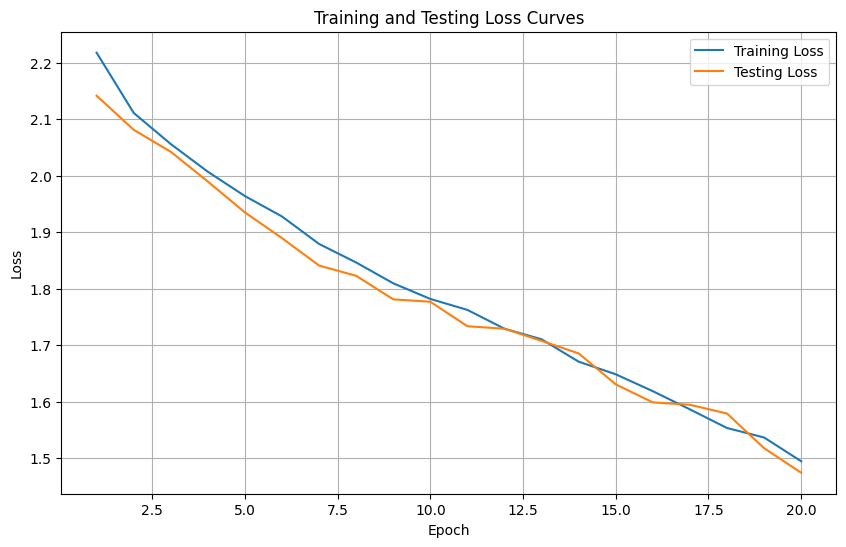

In [103]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import torch.nn as nn

curvy_model, curvy_train, curvy_test = train_vit(
    optimizer_class=Curvy,
    use_curvy=True,
    lr=1e-3,
    hessian_epsilon=1e-2,
    momentum=0.9,
    hessian_compute_interval=50,
    hessian_n_iter=100,
    criterion=nn.CrossEntropyLoss(),
    hessian_computer=hessian,
    train_x=train_x,
    train_y=train_y,
    cuda=True
)


/home/aarsh.wankar/Hessian/DeepHessian/Curvy/curvy.py:64: UserWarning: Hessian computation function, criterion, or data loader not provided. Curvature-based scaling will be disabled.
  warnings.warn(


Epoch 1/20, Train Loss: 2.1703, Test Loss: 2.0774, Test Accuracy: 0.2433
Epoch 2/20, Train Loss: 2.0416, Test Loss: 1.9825, Test Accuracy: 0.2910
Epoch 3/20, Train Loss: 1.9628, Test Loss: 1.9408, Test Accuracy: 0.3152
Epoch 4/20, Train Loss: 1.9066, Test Loss: 1.8567, Test Accuracy: 0.3508
Epoch 5/20, Train Loss: 1.8303, Test Loss: 1.8042, Test Accuracy: 0.3664
Epoch 6/20, Train Loss: 1.7644, Test Loss: 1.7149, Test Accuracy: 0.4104
Epoch 7/20, Train Loss: 1.6898, Test Loss: 1.6551, Test Accuracy: 0.4341
Epoch 8/20, Train Loss: 1.6180, Test Loss: 1.5796, Test Accuracy: 0.4606
Epoch 9/20, Train Loss: 1.5491, Test Loss: 1.5489, Test Accuracy: 0.4808
Epoch 10/20, Train Loss: 1.4955, Test Loss: 1.4795, Test Accuracy: 0.5019
Epoch 11/20, Train Loss: 1.4470, Test Loss: 1.4376, Test Accuracy: 0.5225
Epoch 12/20, Train Loss: 1.4025, Test Loss: 1.4317, Test Accuracy: 0.5261
Epoch 13/20, Train Loss: 1.3836, Test Loss: 1.3690, Test Accuracy: 0.5429
Epoch 14/20, Train Loss: 1.3365, Test Loss: 1.3

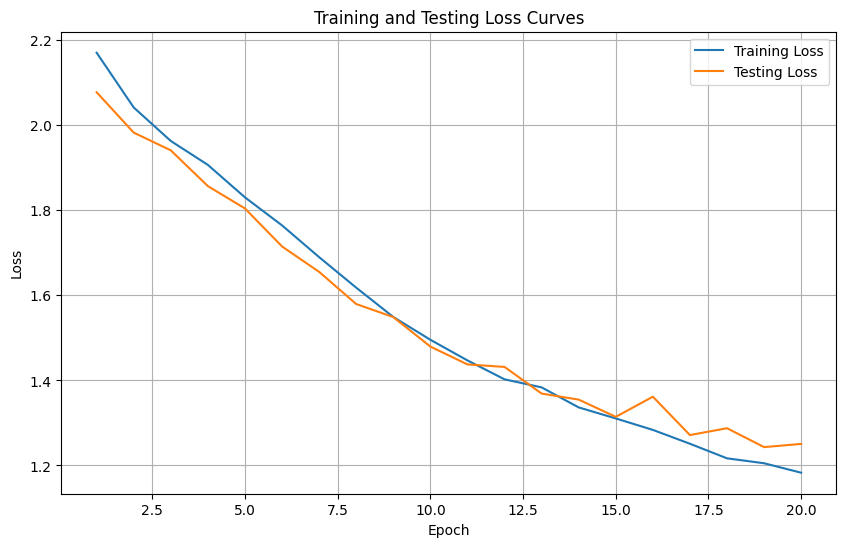

In [17]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import torch.nn as nn

curvy_model, curvy_train, curvy_test = train_vit(
    optimizer_class=Curvy,
    use_curvy=True,
    lr=4e-3,
    hessian_epsilon=4e-5,
    momentum=0.8,
    hessian_compute_interval=200,
    hessian_n_iter=100,
    criterion=nn.CrossEntropyLoss(),
    hessian_computer=hessian,
    # train_x=train_dataset.data,
    # train_y=train_dataset.labels,
    cuda=True
)


In [ ]:
curvy_model, curvy_train, curvy_test = train_vit(
    optimizer_class=Curvy,
    use_curvy=True,
    lr=4e-3,
    hessian_epsilon=4e-5,
    momentum=0.8,
    hessian_compute_interval=200,
    hessian_n_iter=100,
    criterion=nn.CrossEntropyLoss(),
    hessian_computer=hessian,
    # train_x=train_dataset.data,
    # train_y=train_dataset.labels,
    cuda=True
)

In [1]:
from torch.backends.cuda import sdp_kernel

# Make scaled dot product attention fully differentiable (for Hessians etc.)
sdp_kernel.disable_flash()
sdp_kernel.disable_mem_efficient()
sdp_kernel.enable_math()

AttributeError: 'function' object has no attribute 'disable_flash'

In [3]:
import torch
print(torch.__version__)

2.6.0+cu124


In [6]:
from torch.backends.cuda import sdp_kernel
# torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

In [8]:
import torch
import torch.nn as nn
import math
class MHSAPlain(nn.Module):
    """Multi-head self-attention implemented with plain matmuls & softmax.
       This uses only autograd-friendly ops and supports double-backward.
    """
    def __init__(self, dim, num_heads, attn_dropout=0.0, proj_dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_dropout)

    def forward(self, x, mask=None):
        # x: (B, N, dim)
        B, N, D = x.shape
        qkv = self.qkv(x)  # (B, N, 3*D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, heads, N, head_dim)

        # scaled dot product attention (plain ops)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(attn_scores, dim=-1)  # (B, heads, N, N)
        attn = self.attn_drop(attn)
        out = torch.matmul(attn, v)  # (B, heads, N, head_dim)
        out = out.transpose(1, 2).reshape(B, N, D)  # (B, N, dim)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out

In [9]:
class EncoderLayerPlain(nn.Module):
    def __init__(self, dim, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MHSAPlain(dim, nhead, attn_dropout=dropout, proj_dropout=dropout)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, dim),
            nn.Dropout(dropout),
        )

    def forward(self, src, src_mask=None):
        # src: (B, N, dim)
        src2 = self.self_attn(src, mask=src_mask)
        src = src + src2
        src = self.norm1(src)
        src2 = self.ff(src)
        src = src + src2
        src = self.norm2(src)
        return src


In [10]:
class SimpleViTPlain(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=10, dim=256, depth=4, heads=4, mlp_dim=512):
        super().__init__()
        assert image_size % patch_size == 0
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        patch_dim = 3 * patch_size * patch_size

        self.patch_embedding = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        # keep your pos embedding as you had...
        pos_embed = get_2d_sincos_pos_embed(dim, int(math.sqrt(self.num_patches)))
        self.register_buffer('pos_embedding', pos_embed.unsqueeze(0))

        # stack of plain encoder layers
        self.layers = nn.ModuleList([
            EncoderLayerPlain(dim, nhead=heads, dim_feedforward=mlp_dim, dropout=0.0)
            for _ in range(depth)
        ])
        self.mlp_head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p).contiguous()  # same as your code
        x = x.view(B, C, -1, p, p).permute(0, 2, 1, 3, 4)
        x = x.reshape(B, self.num_patches, -1)
        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding

        for layer in self.layers:
            x = layer(x)

        return self.mlp_head(x[:, 0])


In [13]:
model = SimpleViTPlain()
model.train()
inp = torch.randn(2, 3, 224, 224, requires_grad=True)  # input requires grad if you want d2/dx2
out = model(inp)
loss = out.sum()
# first backward (build graph for higher-order grads)
grads = torch.autograd.grad(loss, inp, create_graph=True)[0]
# second derivative (sum of grads -> scalar then grad again)
grad2 = torch.autograd.grad(grads.sum(), inp)
print("second derivative computed:", grad2[0].shape)


second derivative computed: torch.Size([2, 3, 224, 224])


In [15]:
loss = model(inp).sum()
params = [p for p in model.parameters() if p.requires_grad]
grads = torch.autograd.grad(loss, params, create_graph=True)
# take a scalar function of grads then differentiate again
v = sum((g**2).sum() for g in grads)
second_grads = torch.autograd.grad(v, params)  # second derivatives exist


RuntimeError: One of the differentiated Tensors appears to not have been used in the graph. Set allow_unused=True if this is the desired behavior.

In [14]:
import torch
print(torch.__version__)

2.6.0+cu124
